In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import linregress

In [3]:
nav = pd.read_csv(
    r"E:\bluestock_mf_capstone\data\raw\02_nav_history.csv"
)

benchmark = pd.read_csv(
    r"E:\bluestock_mf_capstone\data\raw\10_benchmark_indices.csv"
)

performance = pd.read_csv(
    r"E:\bluestock_mf_capstone\data\raw\07_scheme_performance.csv"
)

nav.head()

,amfi_code,date,nav
0,119551,2022-01-03,54.3856
1,119551,2022-01-04,54.3474
2,119551,2022-01-05,54.6869
3,119551,2022-01-06,55.4550
4,119551,2022-01-07,55.3692


In [4]:
nav["date"] = pd.to_datetime(nav["date"])

nav = nav.sort_values(
    ["amfi_code","date"]
)

nav["daily_return"] = (
    nav.groupby("amfi_code")["nav"]
       .pct_change()
)

nav.head()

,amfi_code,date,nav,daily_return
5750,100016,2022-01-03,520.4608,NaN
5751,100016,2022-01-04,515.0971,-0.010306
5752,100016,2022-01-05,521.7239,0.012865
5753,100016,2022-01-06,515.7880,-0.011377
5754,100016,2022-01-07,515.1639,-0.001210


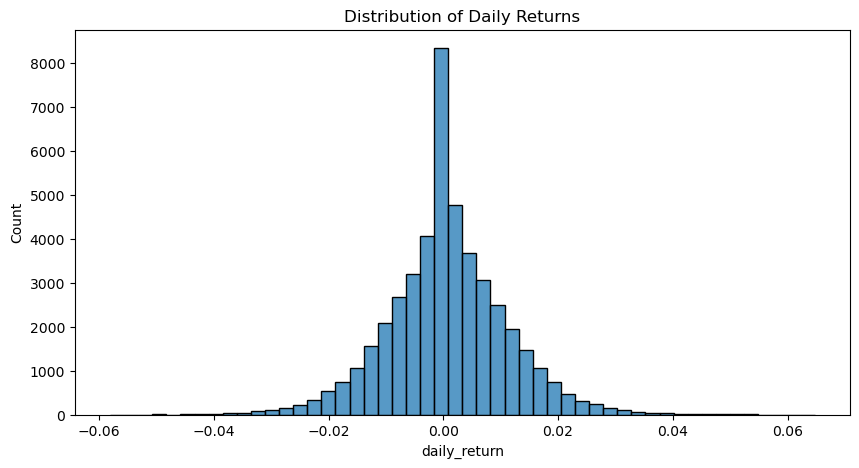

In [5]:
plt.figure(figsize=(10,5))

sns.histplot(
    nav["daily_return"].dropna(),
    bins=50
)

plt.title("Distribution of Daily Returns")

plt.show()

In [6]:
cagr_results = []

for fund in nav["amfi_code"].unique():

    df = nav[
        nav["amfi_code"] == fund
    ].sort_values("date")

    start_nav = df["nav"].iloc[0]
    end_nav = df["nav"].iloc[-1]

    years = (
        (df["date"].iloc[-1] -
         df["date"].iloc[0]).days
    ) / 365

    cagr = (
        (end_nav/start_nav)
        ** (1/years)
        - 1
    )

    cagr_results.append(
        [fund,cagr]
    )

cagr_df = pd.DataFrame(
    cagr_results,
    columns=[
        "amfi_code",
        "cagr"
    ]
)

cagr_df.head()

,amfi_code,cagr
0,100016,0.026352
1,100025,0.044551
2,100033,0.300997
3,101206,0.235205
4,101207,0.079331


In [7]:
rf = 0.065

In [8]:
sharpe_list = []

for fund in nav["amfi_code"].unique():

    temp = nav[
        nav["amfi_code"] == fund
    ]

    mean_ret = (
        temp["daily_return"]
        .mean()
        * 252
    )

    vol = (
        temp["daily_return"]
        .std()
        * np.sqrt(252)
    )

    sharpe = (
        mean_ret - rf
    ) / vol

    sharpe_list.append(
        [fund,sharpe]
    )

sharpe_df = pd.DataFrame(
    sharpe_list,
    columns=[
        "amfi_code",
        "sharpe"
    ]
)

sharpe_df.sort_values(
    "sharpe",
    ascending=False
).head()

,amfi_code,sharpe
34,148567,1.448291
30,120843,1.306744
36,148569,1.234930
19,119551,1.208267
25,120505,1.180101


In [9]:
sortino_list = []

for fund in nav["amfi_code"].unique():

    temp = nav[
        nav["amfi_code"] == fund
    ]

    downside = temp[
        temp["daily_return"] < 0
    ]["daily_return"]

    downside_std = (
        downside.std()
        * np.sqrt(252)
    )

    annual_return = (
        temp["daily_return"]
        .mean()
        * 252
    )

    sortino = (
        annual_return - rf
    ) / downside_std

    sortino_list.append(
        [fund,sortino]
    )

sortino_df = pd.DataFrame(
    sortino_list,
    columns=[
        "amfi_code",
        "sortino"
    ]
)

sortino_df.head()

,amfi_code,sortino
0,100016,-0.351047
1,100025,-0.941821
2,100033,1.829134
3,101206,1.799563
4,101207,0.276644


In [10]:
print(benchmark.columns)

Index(['date', 'index_name', 'close_value'], dtype='object')


In [11]:
benchmark["index_name"].unique()

array(['NIFTY50', 'NIFTY100', 'NIFTY_MIDCAP150', 'BSE_SMALLCAP',
       'NIFTY500', 'CRISIL_LIQUID', 'CRISIL_GILT'], dtype=object)

In [12]:
nifty100 = benchmark[
    benchmark["index_name"] == "NIFTY100"
].copy()

nifty100["date"] = pd.to_datetime(
    nifty100["date"]
)

nifty100 = nifty100.sort_values(
    "date"
)

nifty100["benchmark_return"] = (
    nifty100["close_value"]
    .pct_change()
)

nifty100.head()

,date,index_name,close_value,benchmark_return
1150,2022-01-03,NIFTY100,17778.24,NaN
1151,2022-01-04,NIFTY100,17537.52,-0.013540
1152,2022-01-05,NIFTY100,17607.73,0.004003
1153,2022-01-06,NIFTY100,17556.05,-0.002935
1154,2022-01-07,NIFTY100,17664.02,0.006150


In [13]:
alpha_beta = []

for fund in nav["amfi_code"].unique():

    fund_data = nav[
        nav["amfi_code"] == fund
    ][["date","daily_return"]]

    merged = pd.merge(
        fund_data,
        nifty100[
            ["date","benchmark_return"]
        ],
        on="date",
        how="inner"
    ).dropna()

    if len(merged) > 30:

        beta, intercept, r, p, stderr = linregress(
            merged["benchmark_return"],
            merged["daily_return"]
        )

        alpha = intercept * 252

        alpha_beta.append(
            [fund, alpha, beta]
        )

alpha_beta_df = pd.DataFrame(
    alpha_beta,
    columns=[
        "amfi_code",
        "alpha",
        "beta"
    ]
)

alpha_beta_df.head()

,amfi_code,alpha,beta
0,100016,0.037476,-0.058268
1,100025,0.042818,0.001158
2,100033,0.271954,0.005104
3,101206,0.213998,0.021086
4,101207,0.108971,-0.065289


In [14]:
alpha_beta_df.to_csv(
    r"E:\bluestock_mf_capstone\reports\alpha_beta.csv",
    index=False
)

print("alpha_beta.csv saved")

alpha_beta.csv saved


In [15]:
drawdown_results = []

for fund in nav["amfi_code"].unique():

    temp = nav[
        nav["amfi_code"] == fund
    ].copy()

    temp["running_max"] = (
        temp["nav"]
        .cummax()
    )

    temp["drawdown"] = (
        temp["nav"]
        /
        temp["running_max"]
        - 1
    )

    max_dd = temp[
        "drawdown"
    ].min()

    drawdown_results.append(
        [fund,max_dd]
    )

drawdown_df = pd.DataFrame(
    drawdown_results,
    columns=[
        "amfi_code",
        "max_drawdown"
    ]
)

drawdown_df.head()

,amfi_code,max_drawdown
0,100016,-0.247344
1,100025,-0.043083
2,100033,-0.162172
3,101206,-0.112916
4,101207,-0.354469


In [16]:
print(performance.columns)

Index(['amfi_code', 'scheme_name', 'fund_house', 'category', 'plan',
       'return_1yr_pct', 'return_3yr_pct', 'return_5yr_pct',
       'benchmark_3yr_pct', 'alpha', 'beta', 'sharpe_ratio', 'sortino_ratio',
       'std_dev_ann_pct', 'max_drawdown_pct', 'aum_crore', 'expense_ratio_pct',
       'morningstar_rating', 'risk_grade'],
      dtype='object')


In [17]:
scorecard = performance.copy()

scorecard["return_rank"] = (
    scorecard["return_3yr_pct"]
    .rank(pct=True)
)

scorecard["sharpe_rank"] = (
    scorecard["sharpe_ratio"]
    .rank(pct=True)
)

scorecard["alpha_rank"] = (
    scorecard["alpha"]
    .rank(pct=True)
)

scorecard["expense_rank"] = (
    scorecard["expense_ratio_pct"]
    .rank(
        pct=True,
        ascending=False
    )
)

scorecard["drawdown_rank"] = (
    scorecard["max_drawdown_pct"]
    .rank(
        pct=True,
        ascending=False
    )
)

scorecard.head()

,amfi_code,scheme_name,fund_house,category,plan,return_1yr_pct,return_3yr_pct,return_5yr_pct,benchmark_3yr_pct,alpha,...,max_drawdown_pct,aum_crore,expense_ratio_pct,morningstar_rating,risk_grade,return_rank,sharpe_rank,alpha_rank,expense_rank,drawdown_rank
0,119551,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund,Large Cap,Regular,12.42,12.36,14.45,11.49,0.87,...,-21.70,14288,1.54,4,Moderate,0.375,0.3625,0.2250,0.2625,0.5375
1,119552,SBI Bluechip Fund - Direct Plan - Growth,SBI Mutual Fund,Large Cap,Direct,15.25,11.30,14.23,9.52,1.78,...,-24.43,1231,0.66,3,Moderate,0.175,0.1375,0.8000,0.9250,0.7250
2,119598,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,Small Cap,Regular,24.56,23.39,20.67,22.16,1.23,...,-13.35,19259,1.43,5,Very High,1.000,0.5750,0.5250,0.5000,0.2000
3,119599,SBI Small Cap Fund - Direct Plan - Growth,SBI Mutual Fund,Small Cap,Direct,20.59,23.14,21.82,22.01,1.13,...,-24.78,36061,0.72,4,Very High,0.975,0.5375,0.4625,0.8875,0.7500
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,SBI Mutual Fund,Gilt,Regular,5.34,6.07,5.43,4.47,1.60,...,-2.30,24101,0.77,5,Low,0.075,0.9000,0.7000,0.8000,0.0500


In [18]:
scorecard["fund_score"] = (

      scorecard["return_rank"] * 30

    + scorecard["sharpe_rank"] * 25

    + scorecard["alpha_rank"] * 20

    + scorecard["expense_rank"] * 15

    + scorecard["drawdown_rank"] * 10

)

scorecard["fund_score"] = (
    scorecard["fund_score"]
    .round(2)
)

scorecard[
    ["scheme_name","fund_score"]
].sort_values(
    "fund_score",
    ascending=False
).head()

,scheme_name,fund_score
3,SBI Small Cap Fund - Direct Plan - Growth,72.75
22,Kotak Flexicap Fund - Regular - Growth,71.50
21,Kotak Emerging Equity Fund - Regular - Growth,70.50
29,ABSL Small Cap Fund - Regular - Growth,68.25
2,SBI Small Cap Fund - Regular Plan - Growth,64.38


In [19]:
scorecard.to_csv(
    r"E:\bluestock_mf_capstone\reports\fund_scorecard.csv",
    index=False
)

print("fund_scorecard.csv saved")

fund_scorecard.csv saved


In [20]:
top5 = scorecard.sort_values(
    "fund_score",
    ascending=False
).head(5)

top5[
    ["scheme_name","fund_score"]
]

,scheme_name,fund_score
3,SBI Small Cap Fund - Direct Plan - Growth,72.75
22,Kotak Flexicap Fund - Regular - Growth,71.50
21,Kotak Emerging Equity Fund - Regular - Growth,70.50
29,ABSL Small Cap Fund - Regular - Growth,68.25
2,SBI Small Cap Fund - Regular Plan - Growth,64.38


In [21]:
top5[
    ["scheme_name","fund_score"]
]

,scheme_name,fund_score
3,SBI Small Cap Fund - Direct Plan - Growth,72.75
22,Kotak Flexicap Fund - Regular - Growth,71.50
21,Kotak Emerging Equity Fund - Regular - Growth,70.50
29,ABSL Small Cap Fund - Regular - Growth,68.25
2,SBI Small Cap Fund - Regular Plan - Growth,64.38


In [22]:
nifty50 = benchmark[
    benchmark["index_name"] == "NIFTY50"
].copy()

nifty100 = benchmark[
    benchmark["index_name"] == "NIFTY100"
].copy()

nifty50["date"] = pd.to_datetime(
    nifty50["date"]
)

nifty100["date"] = pd.to_datetime(
    nifty100["date"]
)

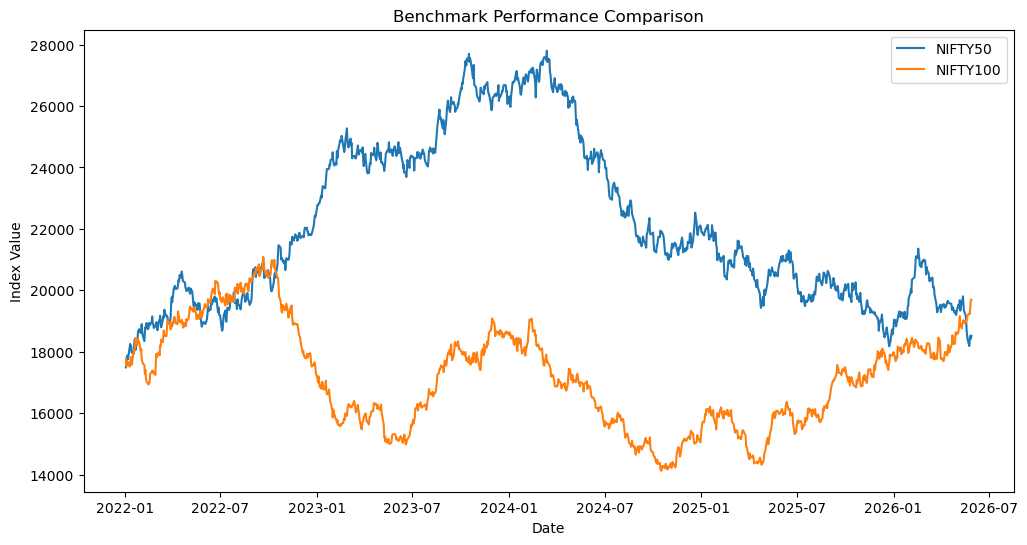

In [23]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.plot(
    nifty50["date"],
    nifty50["close_value"],
    label="NIFTY50"
)

plt.plot(
    nifty100["date"],
    nifty100["close_value"],
    label="NIFTY100"
)

plt.legend()

plt.title(
    "Benchmark Performance Comparison"
)

plt.xlabel("Date")
plt.ylabel("Index Value")

plt.savefig(
    r"E:\bluestock_mf_capstone\reports\benchmark_comparison.png",
    bbox_inches="tight"
)

plt.show()

In [24]:
tracking_error = np.std(
    nifty100["benchmark_return"].dropna()
) * np.sqrt(252)

print(
    "Tracking Error:",
    round(tracking_error,4)
)

KeyError: 'benchmark_return'

In [25]:
print(nifty100.columns)

Index(['date', 'index_name', 'close_value'], dtype='object')


In [26]:
nifty100 = benchmark[
    benchmark["index_name"] == "NIFTY100"
].copy()

nifty100["date"] = pd.to_datetime(
    nifty100["date"]
)

nifty100 = nifty100.sort_values(
    "date"
)

nifty100["benchmark_return"] = (
    nifty100["close_value"]
    .pct_change()
)

nifty100.head()

,date,index_name,close_value,benchmark_return
1150,2022-01-03,NIFTY100,17778.24,NaN
1151,2022-01-04,NIFTY100,17537.52,-0.013540
1152,2022-01-05,NIFTY100,17607.73,0.004003
1153,2022-01-06,NIFTY100,17556.05,-0.002935
1154,2022-01-07,NIFTY100,17664.02,0.006150


In [27]:
print(nifty100.columns)

Index(['date', 'index_name', 'close_value', 'benchmark_return'], dtype='object')


In [28]:
tracking_error = (
    nifty100["benchmark_return"]
    .dropna()
    .std()
    * np.sqrt(252)
)

print(
    "Tracking Error:",
    round(tracking_error,4)
)

Tracking Error: 0.1289


In [29]:
print(nifty100.head())
print(nifty100.columns)

           date index_name  close_value  benchmark_return
1150 2022-01-03   NIFTY100     17778.24               NaN
1151 2022-01-04   NIFTY100     17537.52         -0.013540
1152 2022-01-05   NIFTY100     17607.73          0.004003
1153 2022-01-06   NIFTY100     17556.05         -0.002935
1154 2022-01-07   NIFTY100     17664.02          0.006150
Index(['date', 'index_name', 'close_value', 'benchmark_return'], dtype='object')


In [30]:
import os

print(
    os.path.exists(
        r"E:\bluestock_mf_capstone\reports\fund_scorecard.csv"
    )
)

print(
    os.path.exists(
        r"E:\bluestock_mf_capstone\reports\alpha_beta.csv"
    )
)

print(
    os.path.exists(
        r"E:\bluestock_mf_capstone\reports\benchmark_comparison.png"
    )
)

True
True
True
